# <img src="https://img.icons8.com/bubbles/50/000000/mind-map.png" style="height:50px;display:inline"> ECE 046211 - Technion - Deep Learning
---

## HW2 - Multilayer NNs and Convolutional NNs
---

### <img src="https://img.icons8.com/clouds/96/000000/keyboard.png" style="height:50px;display:inline"> Keyboard Shortcuts
---
* Run current cell: **Ctrl + Enter**
* Run current cell and move to the next: **Shift + Enter**
* Show lines in a code cell: **Esc + L**
* View function documentation: **Shift + Tab** inside the parenthesis or `help(name_of_module)`
* New cell below: **Esc + B**
* Delete cell: **Esc + D, D** (two D's)

### <img src="https://img.icons8.com/bubbles/50/000000/information.png" style="height:50px;display:inline"> Students Information
---
* Fill in

|Name     |Campus Email| ID  |
|---------|--------------------------------|----------|
|Lilach Biton| lilach.biton@campus.technion.ac.il| 205764517|
|Hadassa Levy| Hadassa@campus.technion.ac.il| 316155944|


### <img src="https://img.icons8.com/bubbles/50/000000/upload-to-cloud.png" style="height:50px;display:inline"> Submission Guidelines
---
* Maximal garde: 100.
* Submission only in **pairs**.
    * Please make sure you have registered your group in Moodle (there is a group creation component on the Moodle where you need to create your group and assign members).
* **No handwritten submissions.** You can choose whether to answer in a Markdown cell in this notebook or attach a PDF with your answers.
* <a style='color:red'> SAVE THE NOTEBOOKS WITH THE OUTPUT, CODE CELLS THAT WERE NOT RUN WILL NOT GET ANY POINTS! </a>
* What you have to submit:
    * If you have answered the questions in the notebook, you should submit this file only, with the name: `ece046211_hw2_id1_id2.ipynb`.
    * If you answered the questions in a different file you should submit a `.zip` file with the name `ece046211_hw2_id1_id2.zip` with content:
        * `ece046211_hw2_id1_id2.ipynb` - the code tasks.
        * `ece046211_hw2_id1_id2.pdf` - answers to questions.
    * No other file-types (`.py`, `.docx`...) will be accepted.
* Submission on the course website (Moodle).
* **Latex in Colab** - in some cases, Latex equations may no be rendered. To avoid this, make sure to not use *bullets* in your answers ("* some text here with Latex equations" -> "some text here with Latex equations").

### <img src="https://img.icons8.com/dusk/64/000000/online.png" style="height:50px;display:inline"> Working Online and Locally
---
* You can choose your working environment:
    1. `Jupyter Notebook`, **locally** with <a href="https://www.anaconda.com/distribution/">Anaconda</a> or **online** on <a href="https://colab.research.google.com/">Google Colab</a>
        * Colab also supports running code on GPU, so if you don't have one, Colab is the way to go. To enable GPU on Colab, in the menu: `Runtime`$\rightarrow$ `Change Runtime Type` $\rightarrow$`GPU`.
    2. Python IDE such as <a href="https://www.jetbrains.com/pycharm/">PyCharm</a> or <a href="https://code.visualstudio.com/">Visual Studio Code</a>.
        * Both allow editing and running Jupyter Notebooks.

* Please refer to `Setting Up the Working Environment.pdf` on the Moodle or our GitHub (https://github.com/taldatech/ee046211-deep-learning) to help you get everything installed.
* If you need any technical assistance, please go to our Piazza forum (`hw2` folder) and describe your problem (preferably with images).

### <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> Agenda
---

* [Part 1 - Theory](#-Part-1---Theory)
    * [Q1 - Generalization in A Teacher-Student Setup](#-Question-1--Generalization-in-A-Teacher-Student-Setup)
    * [Q2 - "Typical" Generalization in Multilayer Neural Networks](#-Question-2---"Typical"-Generalization-in-Multilayer-Neural-Networks)
    * [Q3 - Deep Double Descent](#-Question-3---Deep-Double-Descent)
    * [Q4 - Initialization](#-Question-4---Initialization)
    * [Q5 - Equivariance](#-Question-5---Equivariance)
    * [Q6 - VGG Architecture](#-Question-6--VGG-Architecture)
* [Part 2 - Code Assignments](#-Part-2---Code-Assignments)
    * [Task 1 - The Importance of Activation and Initialization](#-Task-1---The-Importance-of-Activation-and-Initialization)
    * [Task 2 - MLP-based Deep Classifer](#-Task-2---MLP-based-Deep-Classifer)
    * [Task 3 - Design a CNN](#-Task-3---Design-a-CNN)
* [Credits](#-Credits)

### <img src="https://img.icons8.com/cute-clipart/64/000000/ball-point-pen.png" style="height:50px;display:inline"> Part 1 - Theory
---
* You can choose whether to answser these straight in the notebook (Markdown + Latex) or use another editor (Word, LyX, Latex, Overleaf...) and submit an additional PDF file, **but no handwritten submissions**.
* You can attach additional figures (drawings, graphs,...) in a separate PDF file, just make sure to refer to them in your answers.

* $\large\LaTeX$ <a href="https://kapeli.com/cheat_sheets/LaTeX_Math_Symbols.docset/Contents/Resources/Documents/index">Cheat-Sheet</a> (to write equations)
    * <a href="http://tug.ctan.org/info/latex-refsheet/LaTeX_RefSheet.pdf">Another Cheat-Sheet</a>

## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 1 -Generalization in A Teacher-Student Setup
---

Recall from lecture 4 the Bayes Risk $\mathcal{\overline{R}}(w)$: $$ \mathcal{\overline{R}}(w) \triangleq \mathbb{E}_{\epsilon \sim \mathcal{N}(0, \sigma_{\epsilon}^2I), w_{true} \sim \mathcal{N}(0,\frac{\sigma_w^2}{d}I) } \left[\mathcal{R}\right], $$ where, $$ \mathcal{R}(w_{\mu}) = ||w_{\mu}-w_{true}||^2 = ||(H_{\mu}^{-1}H-I)w_{true} + H_{\mu}^{-1}X^T\epsilon||^2 $$

Prove:

$$ \overline{\mathcal{R}}(w_{\mu}) = \sum_{i=1}^d \frac{(\sigma_w^2/d) \mu^2 + \sigma_{\epsilon}^2 \lambda_i}{(\lambda_i + \mu)^2} $$

Hints:
* $\mathbb{E} \left[\epsilon^TXH_{\mu}^{-1}H_{\mu}^{-1}X^T\epsilon \right] = \sum_{i,j}^N\mathbb{E}[\epsilon_i \epsilon_j] \left(XH_{\mu}^{-1} \right)_i\left(H_{\mu}^{-1}X^T \right)_j$

* $\mathbb{E}[\epsilon_i \epsilon_j] = \sigma_{\epsilon}^2 \delta_{ij}$

* $\sum_{i=1}^N \left(XH_{\mu}^{-1} \right)_i\left(H_{\mu}^{-1}X^T \right)_i = Tr\left[XH_{\mu}^{-2}X^T \right] $

Solution 1 -Generalization in A Teacher-Student Setup
---

We decompose the expectation using independence of $w_{\text{true}}$ and $\epsilon$:

$$
\bar{R}(w_\mu) = \mathbb{E} \left[ \| (H_\mu^{-1} H - I) w_{\text{true}} \|^2 \right] + \mathbb{E} \left[ \| H_\mu^{-1} X^T \epsilon \|^2 \right]
$$

Use eigendecomposition of $H = X^T X$:

$$
H = U \Lambda U^T \quad \Rightarrow \quad H_\mu^{-1} = (H + \mu I)^{-1} = U (\Lambda + \mu I)^{-1} U^T
$$

Then:

$$
(H_\mu^{-1} H - I) = U \left( (\Lambda + \mu I)^{-1} \Lambda - I \right) U^T
$$

So:

$$
\bar{R}(w_\mu) = \frac{\sigma_w^2}{d}  \cdot \text{Tr} \left[ \left( (\Lambda + \mu I)^{-1} \Lambda - I \right)^2 \right] + \sigma_\epsilon^2 \cdot \text{Tr} \left[ \Lambda (\Lambda + \mu I)^{-2} \right]
$$

Compute each term component-wise:

$$
\left( \frac{\lambda_i}{\lambda_i + \mu} - 1 \right)^2 = \left( \frac{-\mu}{\lambda_i + \mu} \right)^2 = \frac{\mu^2}{(\lambda_i + \mu)^2}
$$

$$
\text{Tr} \left[ \Lambda (\Lambda + \mu I)^{-2} \right] = \sum_{i=1}^{d} \frac{\lambda_i}{(\lambda_i + \mu)^2}
$$


$$
\bar{R}(w_\mu) = \sum_{i=1}^{d} \left( \frac{\frac{\sigma_w^2}{d} \mu^2}{(\lambda_i + \mu)^2} + \frac{\sigma_\epsilon^2 \lambda_i}{(\lambda_i + \mu)^2} \right)
= \sum_{i=1}^{d} \frac{\frac{\sigma_w^2}{d} \mu^2 + \sigma_\epsilon^2 \lambda_i}{(\lambda_i + \mu)^2}
$$



## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 2 - "Typical" Generalization in Multilayer Neural Networks
---


We examine a "student" neural network  $f_{\mathbf{w}}\left(\mathbf{x}\right)$ with parameter vector $\mathbf{w}\in\mathbb{R}^{k}$ and input $\mathbf{x}\in\mathbb{R}^{d_{0}}$  used in a binary classification problem where the training set is $\mathcal{S}=\left\{ \mathbf{x}^{\left(n\right)}\right\} _{n=1}^{N}$ sampled i.i.d. from $P_{X}$, where the binary $\left(\pm1\right)$ labels are generated by a "teacher" neural network $f_{\mathbf{w}_{\star}}\left(\mathbf{x}\right)$ with the same architecture. To understand the "typical" generalization of the student, we examine the following "Guess and Check" algorithm to learn its weights: we randomly sample parameters vectors $\mathbf{w}_{1},\mathbf{w}_{2},...$ i.i.d.from $P_{W}$, in which each parameter is sampled independently from a uniform distribution over $Q=\left\{ -\left(q-1\right)/2,\dots,-1,0,1,\dots,\left(q-1\right)/2\right\} $ quantization levels, where $q=\left|Q\right|$ is an odd positive number (assume that teacher weights are also in $Q$). We do this until a stopping time $t$ in which we perfectly fit the dataset: $\forall n:f_{\mathbf{w}_{t}}\left(\mathbf{x}^{\left(n\right)}\right)=f_{\mathbf{w}_{\star}}\left(\mathbf{x}^{\left(n\right)}\right)$. We examine a two-layer neural network with $d_{1}$ hidden neurons
$$
f_{\mathbf{w}}\left(\mathbf{x}\right)=\mathrm{sign}\left(\mathbf{w}_{2}^{\top}\left[\mathbf{W}_{1}\mathbf{x}\right]_{+}\right)
$$
where $\left[\cdot\right]_{+}$ is the ReLU activation function, the teacher has at most $d_{1}^{\star}<d_{1}$ non-zero neurons (i.e., the other $d_{1}-d_{1}^{\star}$ hidden neurons in the teacher to have all the incoming and outgoing weights equal to zero). Each of the teacher's weights are also in $Q$.

1. Calculate the probability $P_{\mathbf{w}\sim P_{W}}\left(\mathbf{w}=\mathbf{w}_{\star}\right).$
2. Prove that
\begin{equation}
(1) \:\:p_{\star}\triangleq P_{\mathbf{w}\sim P_{W}}\left(\forall\mathbf{x}:f_{\mathbf{w}}\left(\mathbf{x}\right)=f_{\mathbf{w}_{\star}}\left(\mathbf{x}\right)\right)\geq q^{-d_{0}d_{1}^{*}-d_{1}}\,.
\end{equation}
3. Show that for any constant $T>0$, we can bound the probability of stopping time $t>T$ as
\begin{equation} (2) \:\:
\left\lfloor T\right\rfloor \leq\frac{\log P\left(t>T\right)}{\log\left(1-p_{\star}\right)}\,.
\end{equation}
4. Prove the generalization bound:
<br>
   **Theorem 1** *With probability* $\left(1-\eta\right)\left(1-\delta\right)$,
\begin{equation}(3) \:\:
\epsilon<\frac{\left(d_{0}d_{1}^{\star}+d_{1}\right)\log q+\log\frac{1}{\delta}+\log\log\frac{1}{\eta}}{N}
\end{equation}
**Hint**: Combine the results from previous sections, using the approximations $\left\lfloor T\right\rfloor \approx T$ and $\log\left(1-p_{\star}\right)\approx-p_{\star}$ (treat these approximations as exact), and the following basic generalization
 bound (which we learned in class):
<br>
     **Theorem 2** *For any* $f\in\left|\mathcal{F}\right|$ $f\in\left|\mathcal{F}\right|$, *with probability* $1-\delta$,
\begin{equation} (4) \:\:
\epsilon\triangleq\mathbb{P}_{\mathbf{x}}\left(f_{\mathbf{w}}\left(\mathbf{x}\right)\neq f_{\mathbf{w}_{\star}}\left(\mathbf{x}\right)\right)<\frac{\log\left|\mathcal{F}\right|+\log\frac{1}{\delta}}{N}\,.
\end{equation}
6. Is the bound in eq. $(3)$ better than the bound in eq. $(4)$ in which $\mathcal{F}=\left\{ f_{\mathbf{w}}:\mathbf{w}\in Q^{k}\right\} $  is the student hypothesis class (in which each parameter can have one of $q$ values)? Explain and ignore the (negligble) $\log\log\frac{1}{\eta}$ term.

Solution 2 - "Typical" Generalization in Multilayer Neural Networks
---

### **1.**

Each of the $k$ parameters must match exactly. If $w \in Q^k$, since the weights are i.i.d, then:

$$
P(w = w^\star) = q^{-k}
$$

---

### **2.**

We want to lower bound:

$$
p_\star \triangleq P_{w \sim P_W} \left( \forall x: f_w(x) = f_{w^\star}(x) \right)
$$

We require:

* $d_0 d_1^\star$ input weights to match those of the **active** teacher neurons
* $d_1 - d_1^\star$ output weights to be exactly **zero** for the **inactive** neurons

Since each weight is sampled independently:

$$
p_\star \geq q^{-d_0 d_1^\star - d_1}
$$

---

### **3.**

We sample until perfect fit: $f_{w_t}(x^{(n)}) = f_{w^\star}(x^{(n)}) \ \forall n$

At each trial we have probability at least $p_\star$ of success.

So:

$$
P(t > T) \leq (1 - p_\star)^T
\quad \Rightarrow \quad T \leq \frac{\log P(t > T)}{\log(1 - p_\star)}
$$


$$
⇒ T \leq \frac{\log P(t > T)}{\log(1 - p_\star)}
$$

---

### **4.**

Let:

* $\mathcal{F}_T = \{ f_{w_1}, \dots, f_{w_T} \}$
* $\eta = P(t > T)$, so with probability $\geq 1 - \eta$ we stop in time $T$

Then:

$$
\log |\mathcal{F}_T| = \log T \leq \log \left( \frac{\log \eta}{\log (1 - p_\star)} \right)
$$

Using:

* $\log(1 - p_\star) \approx -p_\star$
* $\log \log \frac{1}{\eta} - \log p_\star \leq \log \log \frac{1}{\eta} + (d_0 d_1^\star + d_1) \log q$

$$
≈ log\left(\frac{log (η)}{-p_*}\right) \leq (d_0 d_1^\star + d_1) \log q + \log \log \frac{1}{\eta}
$$

---

### **6.**

Usin eq (1) and eq (2), and the generalization bound eq(4), we get the theorem with $q$ quanyization levels, and since $d_1^\star < d_1$, then:

$$
\log |F| = k \log q = (d_0 d_1 + d_1) \log q
$$

So this new bound is tighter and better explains generalization of sparse teacher networks.


## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 3 - Deep Double Descent
---

For the following plots:
1. Where is the critical point (the point of transition between the "Classical Regime" and "Modern Regime") of the deep double descent?
2. What type of double descent is shown (**look closely at the graph**)? Explain. There can be more than one correct answer.
    

a. <img src='https://raw.githubusercontent.com/taldatech/ee046211-deep-learning/main/assets/double_descent_transformer.PNG' style="height:300px">

b. <img src='https://raw.githubusercontent.com/taldatech/ee046211-deep-learning/main/assets/double_descent_resnet.PNG' style="height:400px">

c. <img src='https://raw.githubusercontent.com/taldatech/ee046211-deep-learning/main/assets/double_descent_intermediate.PNG' style="height:300px">


## Solution 3 - Deep Double Descent

### (a)

#### **1.**

Between model size **200–300**

This is the **interpolation threshold** where the training error reaches zero and the test error spikes — the classical-to-modern transition.

#### **2.**

**Model-wise double descent**

* x-axis: model size
* y-axis: test error
* As model size increases: test error ↓, then ↑ (peak), then ↓ again.

### (b)

#### **1.**

At **model size ≈ 10**

This is a very small architecture where capacity just matches training data, causing overfitting spike.

#### **2.**

**Model-wise double descent**

Same behavior: small model underfits, medium model overfits (test error peak), large model generalizes better.

### (c)

#### **1.**

This graph shows **two axes of overfitting**: training time (epochs) and model size.

#### **2.**

**Both model-wise and epoch-wise double descent**

* For medium models: test error rises as training continues (**epoch-wise descent**).
* For large models: test error shows **model-wise double descent** as model grows.

## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 4 - Initialization
---
Recall that in lecture 5 we were discussing how to calculate the initialization variance, and reached the conclusion that $$ \sigma_l =\frac{1}{\sqrt{\sum_j \mathbb{E} \left[\varphi^2(u_{l-1}[j])\right]}} $$
Show that for ReLU activation ($\varphi(z) = max(0,z)$), the optimal variance satisfies: $$ \sigma_l = \sqrt{\frac{2}{d_{l-1}}}$$

1. Under the assumption that the distribution of $W$ is symmetric ($\to$ the distribution of $u$ is symmetric).
2. Using the central limit theorem for large width.

Answer each section **separately** and assume the sections are independent.

All the notations are the same as in the lecture slides.



## Solution 4 - Initialization

### **1.**


We are interested in computing:

$$
\sum_j \mathbb{E}[\varphi^2(u_{l-1}[j])] = \sum_{j=1}^{d_{l-1}} \mathbb{E}[\max(0, u_{l-1}[j])^2]
$$

Since the distribution is symmetric around zero:

* Half the time $u_{l-1}[j] < 0$, so ReLU outputs 0
* Half the time $u_{l-1}[j] > 0$, and in that case ReLU outputs $u_{l-1}[j]$

This gives:

$$
\mathbb{E}[\varphi^2(u_{l-1}[j])] = \frac{1}{2} \mathbb{E}[u_{l-1}[j]^2 \mid u_{l-1}[j] > 0]
$$

For symmetric distributions (e.g., Gaussian), we have:

$$
\mathbb{E}[u^2] = 2 \cdot \mathbb{E}[u^2 \cdot \mathbb{1}_{u > 0}]
\Rightarrow \mathbb{E}[u^2 \cdot \mathbb{1}_{u > 0}] = \frac{1}{2} \mathbb{E}[u^2]
\Rightarrow \mathbb{E}[\varphi^2(u)] = \frac{1}{2}
$$


Assuming all $u_{l-1}[j]$ are i.i.d. , and there are $d_{l-1}$ such units, we get:

$$
\sum_j \mathbb{E}[\varphi^2(u_{l-1}[j])] = d_{l-1} \cdot \frac{1}{2}
$$

Plug into the original formula:

$$
\sigma_l = \frac{1}{\sqrt{d_{l-1} \cdot \frac{1}{2}}} = \sqrt{\frac{2}{d_{l-1}}}
$$

---

### **2.**

By the Central Limit Theorem, for ReLU $ϕ^2(z)=max(0,z^2) $, and $\mathbb{E}_{z ∼ \mathcal{N}(0,1)}[max(0,z^2)] = \frac{1}{2} \mathbb{E}_{z ∼ \mathcal{N}(0,1)}[z^2] $.


By definition:
$$
Var(z) = \mathbb{E}[z^2] - (\mathbb{E}[z])^2 = 1+0 = 1
$$

Then:

$$
\sigma_l = \frac{1}{\sqrt{d_{l-1} ( \frac{1}{2} \cdot \mathbb{E}[z^2])}} = \sqrt{\frac{2}{d_{l-1}}}
$$


## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 5 - Equivariance
---

Recall from lecture 6:
A function $f: \mathbb{R}^d \to \mathbb{R}^d$ is equivariant if $f(\tau \cdot x) = \tau \cdot f(x)$ for all $\tau$.

Let $f_w(x) = \phi (Wx)$ where $\phi$ is a component-wise non-linearity and $W \in \mathbb{R}^{d\times d}$. Prove that $f_w:\mathbb{R}^d \to \mathbb{R}^d$ is equivariant to transformation family $H$ **if and only if**: $$ \forall \tau \in H, W[i, j] = W[\tau(i), \tau(j)] $$

* As in class, $\tau$ is an operator which re-arranges the terms in the vector it is operating on. $\tau(i)=j$ implies that component $i$ is mapped to component $j$. In addition, $\tau \cdot x$ means we use $\tau$ on $x$.
* Assume one-by-one activations (<a href="https://en.wikipedia.org/wiki/Injective_function">Injective functions/one-by-one</a>)

## Solution 5 - Equivariance

#### Direction 1: If $W[i, j] = W[\tau(i), \tau(j)]$, then $f_w$ is equivariant

We want to prove:

$$
f_w(\tau \cdot x) = \tau \cdot f_w(x)
$$

Since $\phi$ is component-wise and injective, we can compute the $i$-th component of $f_w(\tau \cdot x)$:

$$
\begin{aligned}
[f_w(\tau \cdot x)]_i 
= [\phi(W \cdot (\tau \cdot x))]_i
=\phi\left( \sum_j W[i, j] \cdot x[\tau(j)] \right)
\end{aligned}
$$

let $k = \tau(j) \Rightarrow j = \tau^{-1}(k)$, so:

$$
= \phi\left( \sum_k W[i, \tau^{-1}(k)] \cdot x[k] \right)
$$

Using the assumption that $W[i, \tau^{-1}(k)] = W[\tau(i), k]$:

$$
= \phi\left( \sum_k W[\tau(i), k] \cdot x[k] \right)
= [\phi(Wx)]_{\tau(i)} = [\tau \cdot \phi(Wx)]_i
$$

Thus:

$$
f_w(\tau \cdot x) = \tau \cdot f_w(x)
$$

#### Direction 2: If $f_w(\tau \cdot x) = \tau \cdot f_w(x)$, then $W[i,j] = W[\tau(i), \tau(j)]$

Assume:

$$
f_w(\tau \cdot x) = \tau \cdot f_w(x)
$$

Then for all $i$,

$$
[\phi(W \cdot (\tau \cdot x))]_i = [\tau \cdot \phi(Wx)]_i = \phi((Wx)_{\tau(i)})
$$

From the left-hand side:

$$
[\phi(W \cdot (\tau \cdot x))]_i = \phi\left( \sum_j W[i,j] \cdot x[\tau(j)] \right)
$$

let $k = \tau(j) \Rightarrow j = \tau^{-1}(k)$, so:

$$
= \phi\left( \sum_k W[i, \tau^{-1}(k)] \cdot x[k] \right)
$$

We now equate the arguments inside $\phi$, using injectivity:

$$
\sum_k W[i, \tau^{-1}(k)] \cdot x[k] = \sum_k W[\tau(i), k] \cdot x[k]
$$

Since this must hold for **all** $x$, the coefficients must match:

$$
W[i, \tau^{-1}(k)] = W[\tau(i), k] \quad \forall k
\Rightarrow W[i,j] = W[\tau(i), \tau(j)]
$$


Therefore, from both direction we got:
$$
f_w(x) = \phi(Wx) \text{ is equivariant to all } \tau \in H
\iff
W[i,j] = W[\tau(i), \tau(j)] \quad \forall \tau \in H
$$

## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 6 - VGG Architecture
---

1. The VGG-11 CNN architecture consists of 11 convolution (CONV)/fully-connected (FC) layers (every CONV layer has the same padding and stride, every MAXPOOL layer is 2×2 and has padding of 0 and stride 2). Fill in the table. You need to **consider the bias**.


* CONV$M$-$N$: a convolutional layer of size $M \times M \times N$, where $M$ is the kernel size and $N$ is the number of filters. $stride=1, padding=1$.
* POOL2: $2 \times 2$ Max Pooling with $stride=2$
    * In case the input of the layer is odd, you should round down. For example, if the output of the layer should be $3.5 \times 3.5 \times 3$, you should round to $3 \times 3 \times 3$ (i.e., ignore the last column of the input image when performing MaxPooling).
* FC-N: a fully connected layer with $N$ neurons.


| Layer  | Output Dimension  | Number of Parameters (Weights) |
|---|---|---|
| INPUT  |  224x224x3 | 0  |
|  CONV3-64 | -  | -  |
| ReLU |  - | -  |
| POOL2|  - | -  |
|CONV3-128 | - | -|
|ReLU | - | -|
| POOL2|  - | -  |
|CONV3-256 | - | -|
|ReLU | - | -|
|CONV3-256 | - | -|
|ReLU | - | -|
| POOL2|  - | -  |
|CONV3-512 | - | -|
|ReLU | - | -|
|CONV3-512 | - | -|
|ReLU | - | -|
| POOL2|  - | -  |
|CONV3-512 | - | -|
|ReLU | - | -|
|CONV3-512 | - | -|
|ReLU | - | -|
| POOL2|  - | -  |
| FC-4096|  - | -  |
| FC-4096|  - | -  |
| FC-1000|  - | -  |
| SOFTMAX|  - | -  |

2. What is the total number of parameters? (use a calculator for this one)
3. What percentage of the weights are found in the fully-connected layers?

## Solution 6 - VGG Architecture

### Architecture Description:

* All convolution layers: **3×3 kernels**, stride=1, padding=1.
* All pooling layers: **2×2 max pooling**, stride=2, padding=0.
* Fully connected layers: FC-4096, FC-4096, FC-1000.
* Input: **224×224×3** image
* Bias is included in all CONV and FC layers.
* Round down output size after pooling if not divisible by 2.


### Table of Output Dimensions and Parameters

| Layer     | Output Dimension | Parameters (Weights + Bias)          |
| --------- | ---------------- | ------------------------------------ |
| INPUT     | 224×224×3        | 0                                    |
| CONV3-64  | 224×224×64       | (3×3×3 + 1)×64 = **1,792**           |
| ReLU      | 224×224×64       | 0                                    |
| POOL2     | 112×112×64       | 0                                    |
| CONV3-128 | 112×112×128      | (3×3×64 + 1)×128 = **73,856**        |
| ReLU      | 112×112×128      | 0                                    |
| POOL2     | 56×56×128        | 0                                    |
| CONV3-256 | 56×56×256        | (3×3×128 + 1)×256 = **295,168**      |
| ReLU      | 56×56×256        | 0                                    |
| CONV3-256 | 56×56×256        | (3×3×256 + 1)×256 = **590,080**      |
| ReLU      | 56×56×256        | 0                                    |
| POOL2     | 28×28×256        | 0                                    |
| CONV3-512 | 28×28×512        | (3×3×256 + 1)×512 = **1,180,160**    |
| ReLU      | 28×28×512        | 0                                    |
| CONV3-512 | 28×28×512        | (3×3×512 + 1)×512 = **2,359,808**    |
| ReLU      | 28×28×512        | 0                                    |
| POOL2     | 14×14×512        | 0                                    |
| CONV3-512 | 14×14×512        | (3×3×512 + 1)×512 = **2,359,808**    |
| ReLU      | 14×14×512        | 0                                    |
| CONV3-512 | 14×14×512        | (3×3×512 + 1)×512 = **2,359,808**    |
| ReLU      | 14×14×512        | 0                                    |
| POOL2     | 7×7×512          | 0                                    |
| FC-4096   | 1×1×4096         | (7×7×512 + 1)×4096 = **102,764,544** |
| FC-4096   | 1×1×4096         | (4096 + 1)×4096 = **16,781,312**     |
| FC-1000   | 1×1×1000         | (4096 + 1)×1000 = **4,097,000**      |
| SOFTMAX   | 1×1×1000         | 0                                    |


### Total Number of Parameters

$$
\text{Total} = 1,792 + 73,856 + 295,168 + 590,080 + 1,180,160 + 2,359,808 + 2,359,808 + 2,359,808 + 102,764,544 + 16,781,312 + 4,097,000
$$

$$
\boxed{\text{Total Parameters} = 132,863,336}
$$

### Percentage of Parameters in FC Layers

Only FC layers contribute:

* FC-4096: 102,764,544
* FC-4096: 16,781,312
* FC-1000: 4,097,000

$$
\text{Total in FC} = 123,642,856
$$

$$
\frac{123,642,856}{132,863,336} \approx \boxed{93\% \text{ of parameters are in FC layers}}
$$


### <img src="https://img.icons8.com/officel/80/000000/code.png" style="height:50px;display:inline"> Part 2 - Code Assignments
---
* You must write your code in this notebook and save it with the output of all of the code cells.
* Additional text can be added in Markdown cells.
* You can use any other IDE you like (PyCharm, VSCode...) to write/debug your code, but for the submission you must copy it to this notebook, run the code and save the notebook with the output.

#### Tips
---
1. Uniformly distributed tensors - `torch.Tensor(dim1, dim2, ...,dimN).uniform_(-1, 1)`
2. Separation to **validation set** in PyTorch - <a href="https://gist.github.com/MattKleinsmith/5226a94bad5dd12ed0b871aed98cb123">See example here</a>.

In [2]:
# imports for the practice (you can add more if you need)
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# %matplotlib ipympl
%matplotlib inline

seed = 211
np.random.seed(seed)
torch.manual_seed(seed)

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 1 - The Importance of Activation and Initialization
---
In this task, we are going to use $x \in \mathcal{R}^{512}$ and simple neural network that outputs $f(x) \in \mathcal{R}^{512}$. The network will have 100 layers with 512 units in each layer.

1. We initialize the weights from a unit normal distribution. Run the following code cell and explain what happens. Add a short piece of code that locates when it happens (hint: use `torch.isnan()`). **Print** the layer number.
2. We can demonstrate that at a given layer, the matrix product of inputs $x$ and weight matrix $a$ that is initialized from a standard normal distribution will, on average, have a standard deviation very close to the square root of the number of input connections. For our example, with 512 dimensions, show that for 10,000 multiplications of $a$ and $x$, the empirical standard deviation is similar to the square root of the number of input connections. Use the unbiased version: $$ \hat{std} = \sqrt{\frac{\sum_{i=1}^{10000}\frac{1}{N}\sum_{j=1}^N y^2}{10000}}, $$ where $y=ax$ and $N$ is the number of input connections. **Print** the mean, std and the square root of the number of input connections.
3. For the code from 1, normalize the weight initialization by the square root of the input connections. How does that change the outcome? **Print** the mean and std after the modification.
4. Add a `tanh()` activation after each layer for the code from 1. **Print** the mean and std after the modification. Explain the result.
5. Xavier initialization sets a layer’s weights to values chosen from a random uniform distribution that’s bounded between $$\pm \sqrt{\frac{6}{n_i + n_{i+1}}}$$ where $n_i$ is the number of incoming network connections, or “fan-in,” to the layer, and $ n_{i+1}$ is the number of outgoing network connections from that layer, also known as the “fan-out”. Glorot and Bengio believed that Xavier weight initialization would maintain the variance of activations and back-propagated gradients all the way up or down the layers of a network and demonstrated that networks initialized with Xavier achieved substantially quicker convergence and higher accuracy. Implement **Xavier Uniform** as `xavier_init(fan_in, fan_out)`, a function that returns a tensor initialized according to **Xavier Uniform**. Use it on the simple network from 1 with `tanh` activation. **Print** the mean and std after the modification.
6. If you try to replace the `tanh` activation with `relu` activation in section 5, you will see very different results. Xavier strives to acheive activation outputs of each layer to have a mean of 0 and a standard deviation around 1, on average. When using a ReLU activation, a single layer will, on average have standard deviation that’s very close to the square root of the number of input connections, **divided by the square root of two** ($\sqrt{\frac{512}{2}}$ in our example). **Kaiming He et. al.** proposed an initialization scheme that’s tailored for deep neural nets that use these kinds of asymmetric, non-linear activations. Implement **Kaiming Normal** as `kaiming_init(fan_in, fan_out)`, a function that returns a tensor initialized according to **Kaiming Normal** (use `fan_in` mode). Use it on the simple network from 1 with `relu` activation. **Print** the mean and std after the modification. What happens when you use Xavier with RelU activation?

In [ ]:
# 1.
x = torch.randn(512)
for i in range(100):
    a = torch.randn(512, 512)
    x = a @ x
    if torch.isnan(x).any():
        print(f"NaN occurred at layer {i}")
        break
print(x.mean(), x.std())

NaN occurred at layer 28
tensor(nan) tensor(nan)


1. This fails due to exploding values. Each multiplication scales the variance roughly by a factor of 512. Since the weights initialization in every layer is unnormalized according to the layer depth, the values keep exploding until layer 28, when they reach NaN values.

In [ ]:
# 2.
total_variance = 0.0
total_mean = 0.0

for _ in range(10000):
    a = torch.randn(512, 512)
    x = torch.randn(512)
    y = a @ x
    total_variance += ((y**2).sum().item()) / 512
    total_mean += y.mean().item()

empirical_std = (total_variance / 10000) ** 0.5
mean = (total_mean / 10000)
print(f"Empirical std: {empirical_std:.2f}")
print(f"Empirical mean: {mean:.2f}")
print(f"sqrt(N): {512 ** 0.5:.2f}")

Empirical std: 22.64
Empirical mean: 0.00
sqrt(N): 22.63


In [ ]:
# 3.
x = torch.randn(512)
for i in range(100):
    a = torch.randn(512, 512) / (512 ** 0.5)
    x = a @ x
    if torch.isnan(x).any():
        print(f"NaN occurred at layer {i}")
        break
print(f"Mean: {x.mean().item():.4f}, Std: {x.std().item():.4f}")


Mean: 0.0245, Std: 0.8731


3. The mean stays around zero, and the standard deviation remains stable around 1, without values explosion.

In [ ]:
# 4.
x = torch.randn(512)
for i in range(100):
    a = torch.randn(512, 512)
    x = torch.tanh(a @ x)
    if torch.isnan(x).any():
        print(f"NaN occurred at layer {i}")
        break
print(f"Mean: {x.mean().item():.4f}, Std: {x.std().item():.4f}")

Mean: -0.0020, Std: 0.9807


4. The mean stays around zero, and the standard deviation remains stable around 1, because tanh squashes the activations into [-1, 1], which tends to make each layer's output more or less normalized.

In [ ]:
# 5.
def xavier_init(fan_in, fan_out):
  lim = (6 / (fan_in + fan_out)) ** 0.5
  w = torch.empty(fan_out, fan_in).uniform_(-lim,lim)
  return w

x = torch.randn(512)
for i in range(100):
    a = xavier_init(512, 512)
    x = torch.tanh(a @ x)
    if torch.isnan(x).any():
        print(f"NaN occurred at layer {i}")
        break
print(f"Mean: {x.mean().item():.4f}, Std: {x.std().item():.4f}")

Mean: 0.0017, Std: 0.0634


In [ ]:
# 6.
def kaiming_init(fan_in, fan_out):
  std_norm = (2 / fan_in) ** 0.5
  w = torch.empty(fan_out, fan_in).normal_(mean=0, std=std_norm)
  return w

x = torch.randn(512)
for i in range(100):
    a = kaiming_init(512, 512)
    x = torch.relu(a @ x)
    if torch.isnan(x).any():
        print(f"NaN occurred at layer {i}")
        break
print(f"Mean: {x.mean().item():.4f}, Std: {x.std().item():.4f}")


Mean: 0.1323, Std: 0.1891


In [ ]:
x = torch.randn(512)
for i in range(100):
    a = xavier_init(512, 512)
    x = torch.relu(a @ x)
    if torch.isnan(x).any():
        print(f"NaN occurred at layer {i}")
        break
print(f"Mean: {x.mean().item():.4f}, Std: {x.std().item():.4f}")

Mean: 0.0000, Std: 0.0000


6. With Xavier + ReLU, std and mean vanishes (0.00) over layers because Xavier assumes symmetric activations.

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 2 - MLP-based Deep Classifer
---
In this task you are going to design and train your first neural network for classification.

For this task, we will use the "<a href="https://archive.ics.uci.edu/ml/datasets/MAGIC+Gamma+Telescope">MAGIC Gamma Telescope Data Set"</a>. Cherenkov gamma telescope observes high energy gamma rays, taking advantage of the radiation emitted by charged particles produced inside the electromagnetic showers initiated by the gammas, and developing in the atmosphere. This Cherenkov radiation (of visible to UV wavelengths) leaks through the atmosphere and gets recorded in the detector, allowing reconstruction of the shower parameters. The available information consists of pulses left by the incoming Cherenkov photons on the photomultiplier tubes, arranged in a plane, the camera.

Depending on the energy of the primary gamma, a total of few hundreds to some 10000 Cherenkov photons get collected, in patterns (called the shower image), allowing to discriminate statistically those caused by primary gammas (**signal**) from the images of hadronic showers initiated by cosmic rays in the upper atmosphere (**background**).

Our data has 10 features and 2 classes (signal and background).

1. Load the MAGIC dataset sored in `magic04.data` and display the first 5 features (just run the cell).
2. Separate the data to train, validation and test, reserve 10% of the data for validation and 20% for test.
3. Perform pre-processing steps of your choice and convert the class label from `str` to `int` (for example, `y_train = np.array([0 if y_train[i] == 'g' else 1 for i in range(len(y_train))]).astype(np.int)`).
4. Train a Logistic Regression model from `sklearn` as a baseline for our neural network (only for this section use both the train and validation sets for training the classifier). **Print the test accuracy**.
5. Convert the `numpy` arrays to `torch` tensors with `TensorDataset` as done in the tutorial.
6. Design a **MLP** to classify the data. Optimize the hyper-parameters of your model using the accuracy on the validation set, and when you are satisfied with the model train it on both the train and validation sets and evaluate it on the test set. **You need to reach at least 85% accuracy on the test set, and 87% for a full grade**.
    * You have a free choice of architecture, optimizer, learning scheduler, initialization, regularization and activations.
    * The loss criterion is binary cross entropy: `nn.BCEWithLogitsLoss()` (performs `sigmoid` for you) or `nn.BCELoss` (you need to apply `sigmoid` on the network output yourself).
    * In a Markdown block, write down the chosen architectures and all the hyper-parameters.
        * Make sure to describe any design choice that you used to improve the performance (e.g. if you used a certain regularization or layer, mention it and describe why you think it helped).
    * **Plot** the loss curves (and any oter statistic you want) as a function of epochs/iterations. **Print** the final performance.
    * **Print** the test accuracy.
7. Pick **2** initializations of your choosing and change the initialization of the linear layers and re-train the model (with the same optimal hyper-parameters you found). You can pick an initialization of your choosing from : https://pytorch.org/docs/stable/nn.init.html . See example below how to use. **Print** the change in accuracy for both changes (you should end up with 3 results - original, `init 1` and `init 2`).

In [ ]:
# loading the data
col_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym',  'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
feature_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym',  'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']
data = pd.read_csv("./magic04.data", names=col_names)
X = data[feature_names]
Y = data['class']
data.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
# separate to train, test
"""
Your Code Here
"""
# 1. First split into train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42)

# 2. Then split train+val into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42)

In [ ]:
# pre-processing and converting labels to integers
"""
Your Code Here
"""
# 1. convert lables to integers
y_train = np.array([0 if label == 'g' else 1 for label in y_train]).astype(int)
y_val = np.array([0 if label == 'g' else 1 for label in y_val]).astype(int)
y_test = np.array([0 if label == 'g' else 1 for label in y_test]).astype(int)

# Standardization Z-score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Shuffleing to ensure no order bias
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [ ]:
# training a Logistic Regression baseline - complete the code with your variables
logstic_model = LogisticRegression(solver='lbfgs')
X_train_prep = np.concatenate((X_train, X_val), axis=0)
y_train_np =  np.concatenate((y_train, y_val), axis=0)
y_pred = logstic_model.fit(X_train_prep, y_train_np).predict(X_train_prep)
print("Number of mislabeled points %d out of %d total points."% ((y_train_np != y_pred).sum(), X_train.shape[0]))
print("Logistic Regression Model accuracy =" , logstic_model.score(X_test, y_test))

Number of mislabeled points 3210 out of 13314 total points.
Logistic Regression Model accuracy = 0.7991587802313355


In [ ]:
# create TensorDataset from numpy arrays
"""
Your Code Here
"""
# Convert to Torch Tensors object for be able to work correctly with tensore models
# Convert training set
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # shape: (N, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# Convert validation set
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Convert test set
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
# Prepreperare mini-butches for the model trainig
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Epoch 1: Train Loss = 0.4813, Val Loss = 0.4095
Epoch 2: Train Loss = 0.3768, Val Loss = 0.3800
Epoch 3: Train Loss = 0.3538, Val Loss = 0.3689
Epoch 4: Train Loss = 0.3412, Val Loss = 0.3617
Epoch 5: Train Loss = 0.3334, Val Loss = 0.3548
Epoch 6: Train Loss = 0.3320, Val Loss = 0.3520
Epoch 7: Train Loss = 0.3259, Val Loss = 0.3556
Epoch 8: Train Loss = 0.3236, Val Loss = 0.3515
Epoch 9: Train Loss = 0.3178, Val Loss = 0.3460
Epoch 10: Train Loss = 0.3153, Val Loss = 0.3468
Epoch 11: Train Loss = 0.3129, Val Loss = 0.3441
Epoch 12: Train Loss = 0.3163, Val Loss = 0.3454
Epoch 13: Train Loss = 0.3108, Val Loss = 0.3407
Epoch 14: Train Loss = 0.3136, Val Loss = 0.3414
Epoch 15: Train Loss = 0.3100, Val Loss = 0.3379
Epoch 16: Train Loss = 0.3107, Val Loss = 0.3385
Epoch 17: Train Loss = 0.3080, Val Loss = 0.3398
Epoch 18: Train Loss = 0.3065, Val Loss = 0.3366
Epoch 19: Train Loss = 0.3024, Val Loss = 0.3351
Epoch 20: Train Loss = 0.2997, Val Loss = 0.3371
Epoch 21: Train Loss = 0.3002

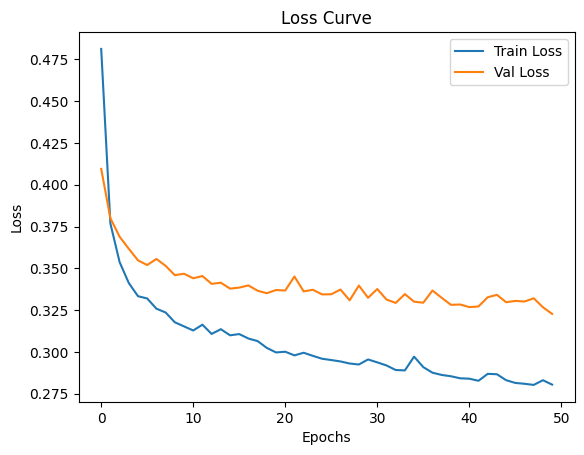

Test Accuracy: 0.8807


In [ ]:
# model, hyoer-paramerters and training
"""
Your Code Here - add as many blocks as you wish
"""
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Define a simple MLP
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # No sigmoid since we use BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.model(x)


def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=50, device='cpu'):
    model.to(device)
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        train_losses.append(total_train_loss / len(train_loader))

        # Validation
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                total_val_loss += loss.item()
        val_losses.append(total_val_loss / len(val_loader))

        print(f"Epoch {epoch+1}: Train Loss = {train_losses[-1]:.4f}, Val Loss = {val_losses[-1]:.4f}")

    return train_losses, val_losses


def evaluate(model, test_loader, device='cpu'):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predictions = torch.sigmoid(outputs) > 0.5
            correct += (predictions.float() == y_batch).sum().item()
            total += y_batch.size(0)
    print(f"Test Accuracy: {correct / total:.4f}")


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Initialize model, loss, optimizer
model = MLP(input_size=X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train
train_losses, val_losses = train_model(model, train_loader, val_loader, optimizer, criterion, epochs=50, device=device)

# Plot loss curves
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

# Final test accuracy
evaluate(model, test_loader, device)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.init as init
import math

class MyModel(nn.Module):
    def __init__(self, input_size, init_type=None):
        super(MyModel, self).__init__()
        self.init_type = init_type

        # Model layers
        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 1)  # No sigmoid for BCEWithLogitsLoss

        # Apply custom initialization
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if self.init_type == 'kaiming':
                    init.kaiming_normal_(m.weight, nonlinearity='relu')
                elif self.init_type == 'xavier':
                    init.xavier_uniform_(m.weight)
                elif self.init_type == 'normal':
                    init.normal_(m.weight, mean=0.0, std=0.01)
                else:
                    # Default PyTorch init if none provided
                    continue
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        output = self.fc3(x)
        return output


In [ ]:
# Original (PyTorch default)
model_default = MyModel(input_size=X_train.shape[1], init_type=None)
optimizer = optim.Adam(model_default.parameters(), lr=0.001)
train_model(model_default, train_loader, val_loader, optimizer, criterion, epochs=50, device=device)
print("Original model accuracy:")
evaluate(model_default, test_loader, device)

# Kaiming
model_kaiming = MyModel(input_size=X_train.shape[1], init_type='kaiming')
optimizer = optim.Adam(model_kaiming.parameters(), lr=0.001)
train_model(model_kaiming, train_loader, val_loader, optimizer, criterion, epochs=50, device=device)
print("Kaiming model accuracy:")
evaluate(model_kaiming, test_loader, device)

# Xavier
model_xavier = MyModel(input_size=X_train.shape[1], init_type='xavier')
optimizer = optim.Adam(model_xavier.parameters(), lr=0.001)
train_model(model_xavier, train_loader, val_loader, optimizer, criterion, epochs=50, device=device)
print("Xavier model accuracy:")
evaluate(model_xavier, test_loader, device)


Epoch 1: Train Loss = 0.4579, Val Loss = 0.4036
Epoch 2: Train Loss = 0.3707, Val Loss = 0.3832
Epoch 3: Train Loss = 0.3482, Val Loss = 0.3708
Epoch 4: Train Loss = 0.3392, Val Loss = 0.3614
Epoch 5: Train Loss = 0.3339, Val Loss = 0.3574
Epoch 6: Train Loss = 0.3270, Val Loss = 0.3544
Epoch 7: Train Loss = 0.3216, Val Loss = 0.3525
Epoch 8: Train Loss = 0.3197, Val Loss = 0.3503
Epoch 9: Train Loss = 0.3146, Val Loss = 0.3500
Epoch 10: Train Loss = 0.3137, Val Loss = 0.3462
Epoch 11: Train Loss = 0.3110, Val Loss = 0.3496
Epoch 12: Train Loss = 0.3088, Val Loss = 0.3452
Epoch 13: Train Loss = 0.3072, Val Loss = 0.3432
Epoch 14: Train Loss = 0.3054, Val Loss = 0.3424
Epoch 15: Train Loss = 0.3037, Val Loss = 0.3411
Epoch 16: Train Loss = 0.3087, Val Loss = 0.3432
Epoch 17: Train Loss = 0.3005, Val Loss = 0.3382
Epoch 18: Train Loss = 0.2999, Val Loss = 0.3383
Epoch 19: Train Loss = 0.2983, Val Loss = 0.3364
Epoch 20: Train Loss = 0.3000, Val Loss = 0.3354
Epoch 21: Train Loss = 0.2952

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 3 - Design a CNN
---
In this task you are going to design a deep convolutional neural network to classify 10 classes from Imagenet (tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute) - **The Imagenette Dataset**.

* 10 classes, 1 for each object.
* 9469 images for training and 3925 for testing (70/30 separation).
* We will use a downscaled version where the images are resized to $64\times 64$ resolution.

<center><img src="https://storage.googleapis.com/tfds-data/visualization/fig/imagenette-160px-v2-1.0.0.png" style="height:300px"></center>

1. Load the the Imagenette dataset with PyTorch using `torchvision.datasets.Imagenette(
    root='./datasets', split='train', size='160px', download=True, transform=transform_train)`, where `split` is either `'train'` or `'val'`, you can read more here: https://pytorch.org/vision/main/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette . Use the `transform` parameter to resize the images to $64 \times 64$ (for train, validation and test) and convert the data to tensors, e.g.,
   
   <code>transform_test=transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),])</code>
    
   Display 5 images from the train set.

   <a href="https://gist.github.com/kevinzakka/d33bf8d6c7f06a9d8c76d97a7879f5cb">Train, Validation and Test Split for torchvision Datasets</a>
3. Design a Convolutional Neural Network (CNN) to classify classes from the images.
    * You are **not allowed** to use `BatchNorm` in your architecture, but can use any other normalization (`GroupNorm`, `LayerNorm`, and etc..).
    * Describe the chosen architecture, how many layers? What activations did you choose? What are the filter sizes? Did you use fully-connected layers (if you did, explain their sizes)?
    * What is the input dimension? What is the output dimension?
    * Calculate the number of parameters (weights) in the network. What is the model size in MegaBytes (MB)? (see the convolution tutorial). **Print** these numbers.
4. Train the classifier (preferably on a GPU - use Colab for this part if you don't have a GPU).
    * **DO NOT USE ANY IMAGE AUGMENTATIONS IN THIS PART** (You can still use `Normalize` if you wish, but no cropping, flipping and etc...).
    * You are not allowed to use pre-trained models (i.e., no transfer learning, only learning from scratch).
    * Describe the hyper-parameters of the model (batch size, epochs, optimizer, learning rate, scheduler....). How did you tune your model? Did you use a validation set to tune the model?
    * What is the final accuracy on the test set? **Print** it.
        * You need to reach at least 73% accuracy in this section, and 78% for maximum points in section 5.
    * **Plot** the loss curves (and any other statistic you calculate) as a function of epochs/iterations.
6. For the trained classifier, what is the accuracy on the test set when each test image is added a small noise $a=(0.05, 0.01, 0.005)$: $$ \text{image} + a \times \mathcal{N}(0, 1).$$ **Print** the result for each value of $a$.
7. Retrain the classifier, but this time use data augementations of your choosing. Briefly explain what augmentation you chose and how it works. Did the test accuracy improve? **Print** the result.
    * You can use transformations available in `torchvision.transforms` as shown in the tutorial.
    * You are welcome to use <a href="https://kornia.github.io/">`kornia`</a> for the augmentations (**2 points bonus**, maximal grade is still 100).
    * **Plot** the loss curves (and any other statistic you want) as a function of epochs/iterations.

In [ ]:
# 1.
# load Imagenette dataset
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.ToTensor()])

train_data = torchvision.datasets.Imagenette( root='./datasets', split='train', size='160px', download=True, transform=transform)
val_data = torchvision.datasets.Imagenette( root='./datasets', split='train', size='160px', download=True, transform=transform)
test_data = torchvision.datasets.Imagenette( root='./datasets', split='val', size='160px', download=True, transform=transform)


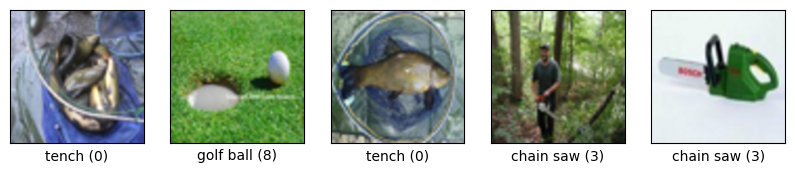

In [74]:
# display 5 images from the train set
label_names = ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']

def plot_images(images, cls_true, cls_pred=None):
    """
    Adapted from https://github.com/Hvass-Labs/TensorFlow-Tutorials/
    """
    fig, axes = plt.subplots(1, 5, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        # plot img
        ax.imshow(images[i, :, :, :], interpolation='spline16')

        # show true & predicted classes
        cls_true_name = label_names[cls_true[i]]
        if cls_pred is None:
            xlabel = "{0} ({1})".format(cls_true_name, cls_true[i])
        else:
            cls_pred_name = label_names[cls_pred[i]]
            xlabel = "True: {0}\nPred: {1}".format(
                cls_true_name, cls_pred_name
            )
        ax.set_xlabel(xlabel)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

sample_loader = torch.utils.data.DataLoader(train_data, batch_size=5, shuffle=True)
data_iter = iter(sample_loader)
images, labels = next(data_iter)
X = images.numpy().transpose([0, 2, 3, 1])
plot_images(X, labels)

In [ ]:
# 2.
# design a CNN for Imagenette dataset
class ImagenetteCNN(nn.Module):

    def __init__(self):
        """CNN Builder."""
        super(ImagenetteCNN, self).__init__()

        self.conv_layer = nn.Sequential(

            # Conv Layer block 1
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.GroupNorm(4, 16),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.LeakyReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # input_resolution / 2 = 64 / 2 = 32

            # Conv Layer block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.LeakyReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # input_resolution / 4 = 64 / 4 = 16
            nn.Dropout2d(p=0.05),

            # Conv Layer block 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.LeakyReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # input_resolution / 8 = 64 / 8 = 8
            # the output dimensions: [batch_size, 128, h=input_resolution / 8, w=input_resolution / 8]
        )

        self.fc_layer = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(8192, 10),  # 128 * 8 * 8 = 16384
        )

    def forward(self, x):
        """Perform forward."""

        # conv layers
        x = self.conv_layer(x)  # [batch_size, channels=256, h_f=8, w_f=8]

        # flatten - can also use nn.Flatten() in __init__() instead
        x = x.view(x.size(0), -1)  # [batch_size, channels * h_f * w_f=16384]

        # fc layer
        x = self.fc_layer(x)  # [batch_size, n_classes=10]

        return x

2. 
* **Input shape:** `(3, 64, 64)` (RGB image, 64×64 pixels)
* **Output shape:** `[10]` (logits for 10 classes)


### **Convolutional Layers**

We use 3 convolutional blocks. Each block contains two convolutional layers, Group Normalization (GN), and LeakyReLU activations. MaxPooling is applied at the end of each block, and dropout is added after some blocks.

1. **Conv Block 1**

   * Conv2d: `in_channels=3`, `out_channels=16`, `kernel_size=3`, `padding=1`
   * GroupNorm: `num_groups=4`, `num_channels=16`
   * Activation: LeakyReLU
   * Conv2d: `16 → 32`, `kernel_size=3`, `padding=1`
   * Activation: LeakyReLU
   * MaxPool2d: `kernel_size=2`, `stride=2`
   * **Output shape:** `(32, 32, 32)`

2. **Conv Block 2**

   * Conv2d: `32 → 64`, `kernel_size=3`, `padding=1`
   * GroupNorm: `num_groups=8`, `num_channels=64`
   * Activation: LeakyReLU
   * Conv2d: `64 → 64`, `kernel_size=3`, `padding=1`
   * Activation: LeakyReLU
   * MaxPool2d: `kernel_size=2`, `stride=2`
   * Dropout2d: `p=0.05`
   * **Output shape:** `(64, 16, 16)`

3. **Conv Block 3**

   * Conv2d: `64 → 128`, `kernel_size=3`, `padding=1`
   * GroupNorm: `num_groups=8`, `num_channels=128`
   * Activation: LeakyReLU
   * Conv2d: `128 → 128`, `kernel_size=3`, `padding=1`
   * Activation: LeakyReLU
   * MaxPool2d: `kernel_size=2`, `stride=2`
   * **Output shape:** `(128, 8, 8)`


### **Fully Connected Layers**

We flatten the output of the last conv layer and pass it through one fully connected layer:

* **Flattened shape:** `128 × 8 × 8 = 8192`

1. **Dropout:** `p=0.5`
2. **Linear Layer:** `in_features=8192`, `out_features=10` (for 10 classes)
3. **Output shape:** `(10,)`


### **Activations Used**

* **LeakyReLU** is used after every convolutional layer.
* We use `CrossEntropyLoss`, which applies **softmax** internally.

#### **Summary Table**

| Layer             | Configuration                     | Output Shape  |
| ----------------- | --------------------------------- | ------------- |
| Input             | -                                 | (3, 64, 64)   |
| Conv + GN + ReLU  | 3 → 16, kernel=3, pad=1, GN(4)    | (16, 64, 64)  |
| Conv + ReLU       | 16 → 32, kernel=3, pad=1          | (32, 64, 64)  |
| MaxPool           | kernel=2, stride=2                | (32, 32, 32)  |
| Conv + GN + ReLU  | 32 → 64, kernel=3, pad=1, GN(8)   | (64, 32, 32)  |
| Conv + ReLU       | 64 → 64, kernel=3, pad=1          | (64, 32, 32)  |
| MaxPool + Dropout | kernel=2, stride=2, Dropout(0.05) | (64, 16, 16)  |
| Conv + GN + ReLU  | 64 → 128, kernel=3, pad=1, GN(8)  | (128, 16, 16) |
| Conv + ReLU       | 128 → 128, kernel=3, pad=1        | (128, 16, 16) |
| MaxPool           | kernel=2, stride=2                | (128, 8, 8)   |
| Flatten           | -                                 | (8192,)       |
| Dropout + FC      | Dropout(0.5), Linear(8192 → 10)   | (10,)         |


In [76]:
# calculate the number of parameters and model size
dummy_model = ImagenetteCNN()
num_params = sum(p.numel() for p in dummy_model.parameters())

param_size = 0
for param in dummy_model.parameters():
  param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in dummy_model.buffers():
  buffer_size += buffer.nelement() * buffer.element_size()
size_all_mb = (param_size + buffer_size) / 1024 ** 2

print(f"Number of parameters: {num_params}")
print(f"model size: {size_all_mb:.2f} MB")

Number of parameters: 364298
model size: 1.39 MB


In [77]:
# 3.
# train the classifier
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Hyperparameters
num_epochs = 30
learning_rate = 5e-4
batch_size = 64

# Model
model = ImagenetteCNN().to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)


Using device: cuda


3.
#### **Hyperparameters**

| Hyperparameter     | Value                    |
| ------------------ | ------------------------ |
| Batch size         | **64**                   |
| Number of epochs   | **30**                   |
| Optimizer          | **Adam**                 |
| Learning rate      | **5e-4**                 |
| Loss function      | **CrossEntropyLoss**     |
| Scheduler          | **ReduceLROnPlateau**    |
| Scheduler patience | **1**             |
| Scheduler factor   | **0.5** (halves the LR)  |
| Validation split   | **10%** of training data |

#### **Validation Set**

We split **10%** of the training set as a validation set. This was done using a `SubsetRandomSampler`. The validation set was used both for tuning the learning rate through the scheduler and for checking overfitting during training.

#### **Model Tuning Strategy**

We tuned the model iteratively based on validation performance:

* **Initial Learning Rate**: We chose a relatively conservative learning rate (`5e-4`) to ensure stable convergence.
* **Scheduler**: We used a `ReduceLROnPlateau` scheduler with validation accuracy, reducing the learning rate by a factor of **0.5** if accuracy did not improve for **2 epochs**. This helps fine-tune the model toward convergence.
* **Epoch Count**: We trained for **30 epochs**, which was sufficient for convergence on the small Imagenette dataset.
* **Validation Accuracy**: After each epoch, we computed validation accuracy and used it to trigger learning rate reductions and evaluate generalization.

In [78]:
from torch.utils.data.sampler import SubsetRandomSampler
# split train validation datasets
val_size = 0.1

num_train = len(train_data)
indices = list(range(num_train))
split = int(np.floor(val_size * num_train))

np.random.shuffle(indices)
train_idx, valid_idx = indices[split:], indices[:split]
print(f"Train size: {len(train_idx)}")
print(f"Validation size: {len(valid_idx)}")
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# train, val, test loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, pin_memory=True)
valid_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, sampler=valid_sampler, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True, pin_memory=True)

Train size: 8523
Validation size: 946


In [79]:
# function to calcualte accuracy of the model
def calculate_accuracy(model, dataloader, device):
  model.eval() # put in evaluation mode, turn off Dropout, BatchNorm uses learned statis
  total_correct = 0
  total_images = 0
  confusion_matrix = np.zeros([10, 10], int)
  with torch.no_grad():
    for data in dataloader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total_images += labels.size(0)
      total_correct += (predicted == labels).sum().item()
      for i, l in enumerate(labels):
        confusion_matrix[l.item(), predicted[i].item()] += 1
        model_accuracy = total_correct / total_images * 100
  return model_accuracy, confusion_matrix

In [80]:
import time

train_losses = []
val_losses = []
val_accuracies = []

# training loop
for epoch in range(1, num_epochs + 1):
  model.train() # put in training mode, turn on Dropout, BatchNorm uses batch's statisti
  running_loss = 0.0
  epoch_time = time.time()

  for images, labels in train_loader:
    # send them to device
    images = images.to(device)
    labels = labels.to(device)

    # forward + backward + optimize
    outputs = model(images) # forward pass
    loss = criterion(outputs, labels) # calculate the loss
    # always the same 3 steps
    optimizer.zero_grad() # zero the parameter gradients
    loss.backward() # backpropagation
    optimizer.step() # update parameters

    # print statistics
    running_loss += loss.data.item()

  # # Normalizing the loss by the total number of train batches
  running_loss /= len(train_loader.sampler)

  # Validation
  model.eval()
  val_loss = 0.0

  with torch.no_grad():
      for images, labels in valid_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)
          val_loss += loss.item()

  # train_loss_avg = running_loss / len(train_loader.sampler)
  val_loss_avg = val_loss / len(valid_loader.sampler)

  # Calculate training/test set accuracy of the existing model
  train_accuracy, train_confusion_matrix = calculate_accuracy(model, train_loader, device)
  val_accuracy, val_confusion_matrix = calculate_accuracy(model, valid_loader, device)

  # Update the learning rate scheduler based on validation accuracy
  scheduler.step(val_accuracy)
  current_lr = scheduler.get_last_lr()[0]

  train_losses.append(running_loss)
  val_losses.append(val_loss_avg)
  val_accuracies.append(val_accuracy)

  log = "Epoch: {} | Loss: {:.4f} | Training accuracy: {:.3f}% | Val Loss: {:.4f} | Val Accuracy: {:.2f}% | Epoch Time: {:.2f} secs".format(epoch, running_loss, train_accuracy, val_loss_avg, val_accuracy, test_accuracy, time.time() - epoch_time)

  print(log)
  print(f"Epoch {epoch+1}: learning rate is {current_lr}")


Epoch: 1 | Loss: 0.0328 | Training accuracy: 36.654% | Val Loss: 0.0292 | Val Accuracy: 34.99% | Epoch Time: 74.65 secs
Epoch 2: learning rate is 0.0005
Epoch: 2 | Loss: 0.0263 | Training accuracy: 53.479% | Val Loss: 0.0237 | Val Accuracy: 49.47% | Epoch Time: 74.65 secs
Epoch 3: learning rate is 0.0005
Epoch: 3 | Loss: 0.0220 | Training accuracy: 62.525% | Val Loss: 0.0205 | Val Accuracy: 55.81% | Epoch Time: 74.65 secs
Epoch 4: learning rate is 0.0005
Epoch: 4 | Loss: 0.0197 | Training accuracy: 59.510% | Val Loss: 0.0233 | Val Accuracy: 53.07% | Epoch Time: 74.65 secs
Epoch 5: learning rate is 0.0005
Epoch: 5 | Loss: 0.0175 | Training accuracy: 67.136% | Val Loss: 0.0190 | Val Accuracy: 61.52% | Epoch Time: 74.65 secs
Epoch 6: learning rate is 0.0005
Epoch: 6 | Loss: 0.0156 | Training accuracy: 74.809% | Val Loss: 0.0165 | Val Accuracy: 64.90% | Epoch Time: 74.65 secs
Epoch 7: learning rate is 0.0005
Epoch: 7 | Loss: 0.0143 | Training accuracy: 75.572% | Val Loss: 0.0166 | Val Accu

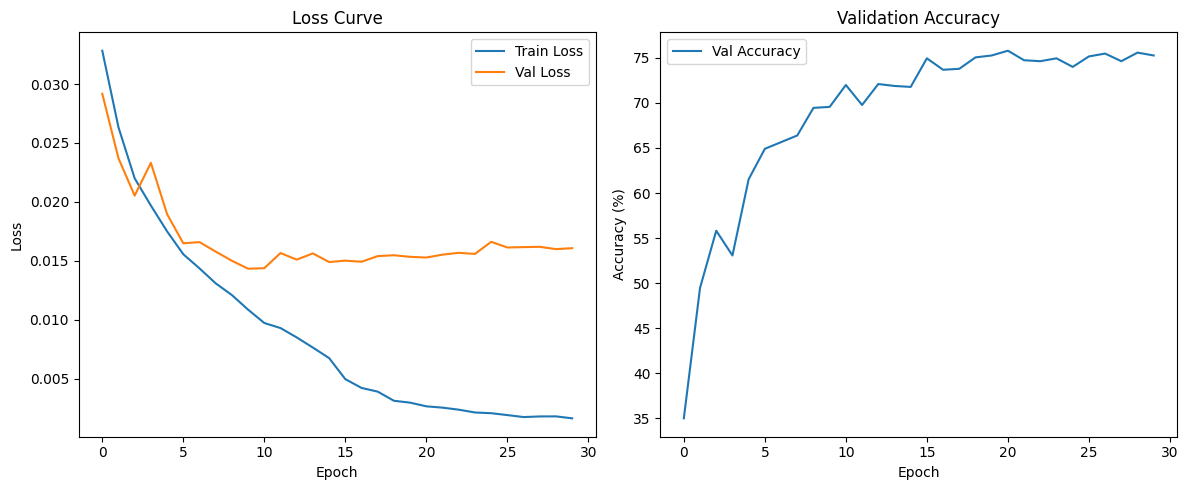

In [81]:
# plot the training and validation loss and accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()


test accuracy: 73.019%


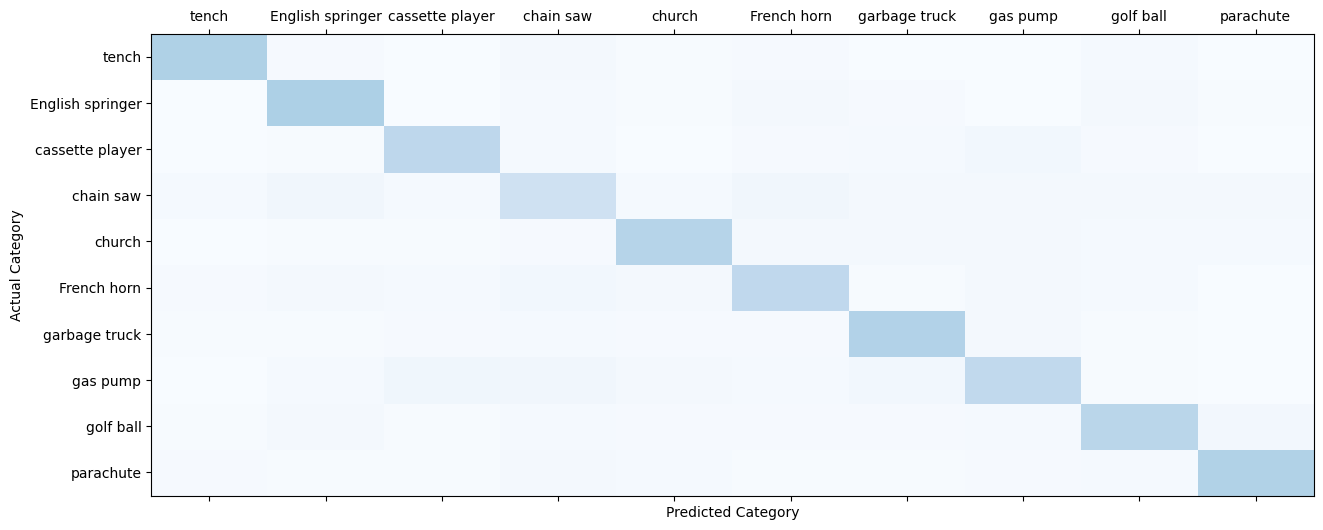

In [82]:
# calculate accuracy and confusion matrix
test_accuracy, confusion_matrix = calculate_accuracy(model, test_loader, device)
print("test accuracy: {:.3f}%".format(test_accuracy))

# plot confusion matrix
fig, ax = plt.subplots(1,1,figsize=(15,6))
ax.matshow(confusion_matrix, aspect='auto', vmin=0, vmax=1000, cmap=plt.get_cmap('Blues'))
plt.ylabel('Actual Category')
plt.yticks(range(10), label_names)
plt.xlabel('Predicted Category')
plt.xticks(range(10), label_names)
plt.show()

In [83]:
# 4.
# test the model with noise
def test_with_noise(model, a):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            noise = a * torch.randn_like(inputs)
            noisy_inputs = torch.clamp(inputs + noise, 0, 1).to(device)
            labels = labels.to(device)
            outputs = model(noisy_inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total * 100

for a in [0.05, 0.01, 0.005]:
    acc = test_with_noise(model, a)
    print(f"Accuracy with noise a={a}: {acc:.2f}%")


Accuracy with noise a=0.05: 69.81%
Accuracy with noise a=0.01: 72.64%
Accuracy with noise a=0.005: 72.94%


In [ ]:
# 5.
# data augmentation for Imagenette dataset
transform_train_aug = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.RandomCrop(size=(64, 64), padding=4),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    torchvision.transforms.ToTensor()])

train_data = torchvision.datasets.Imagenette( root='./datasets', split='train', size='160px', download=True, transform=transform_train_aug)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, pin_memory=True)

#### **Explanation of Each Augmentation**

| Augmentation                | Description                                                                                                                                                            |
| --------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| RandomCrop | Randomly crops a **64×64** patch from the image after adding **4 pixels of padding** on each side. This introduces positional variance and mimics slight translations. |
| RandomHorizontalFlip    | Flips the image horizontally with a **50% probability**, helping the model learn mirror-invariant features.                                                            |
| ColorJitter          | Randomly adjusts **brightness**, **contrast**, **saturation**, and **hue** to simulate lighting and color variations that occur in natural images.                     |

This augmentation strategy increases the diversity of the training set by introducing small, realistic variations in appearance and position, leading to a more robust and generalizable model.


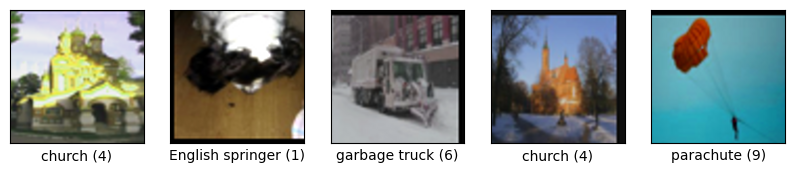

In [85]:
sample_loader = torch.utils.data.DataLoader(train_data, batch_size=5, shuffle=True)
data_iter = iter(sample_loader)
images, labels = next(data_iter)
X = images.numpy().transpose([0, 2, 3, 1])
plot_images(X, labels)

In [86]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Model
model = ImagenetteCNN().to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

Using device: cuda


In [87]:
import time

train_losses = []
val_losses = []
val_accuracies = []

# training loop
for epoch in range(1, num_epochs + 1):
  model.train() # put in training mode, turn on Dropout, BatchNorm uses batch's statisti
  running_loss = 0.0
  epoch_time = time.time()
  for images, labels in train_loader:
    # send them to device
    images = images.to(device)
    labels = labels.to(device)

    # forward + backward + optimize
    outputs = model(images) # forward pass
    loss = criterion(outputs, labels) # calculate the loss
    # always the same 3 steps
    optimizer.zero_grad() # zero the parameter gradients
    loss.backward() # backpropagation
    optimizer.step() # update parameters

    # print statistics
    running_loss += loss.data.item()

  # # Normalizing the loss by the total number of train batches
  running_loss /= len(train_loader.sampler)

  # Validation
  model.eval()
  val_loss = 0.0
  with torch.no_grad():
      for images, labels in valid_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)
          val_loss += loss.item()

  # train_loss_avg = running_loss / len(train_loader.sampler)
  val_loss_avg = val_loss / len(valid_loader.sampler)

  # Calculate training/test set accuracy of the existing model
  train_accuracy, train_confusion_matrix = calculate_accuracy(model, train_loader, device)
  val_accuracy, test_confusion_matrix = calculate_accuracy(model, valid_loader, device)

  # Update the learning rate scheduler based on validation accuracy
  scheduler.step(val_accuracy)
  current_lr = scheduler.get_last_lr()[0]

  train_losses.append(running_loss)
  val_losses.append(val_loss_avg)
  val_accuracies.append(val_accuracy)

  log = "Epoch: {} | Loss: {:.4f} | Training accuracy: {:.3f}% |Val Loss: {:.4f} | Val Accuracy: {:.2f}% | Epoch Time: {:.2f} secs".format(epoch, running_loss, train_accuracy, val_loss_avg, val_accuracy, test_accuracy, time.time() - epoch_time)

  print(log)
  print(f"Epoch {epoch+1}: learning rate is {current_lr}")

Epoch: 1 | Loss: 0.0319 | Training accuracy: 38.942% |Val Loss: 0.0287 | Val Accuracy: 38.16% | Epoch Time: 73.02 secs
Epoch 2: learning rate is 0.0005
Epoch: 2 | Loss: 0.0259 | Training accuracy: 50.557% |Val Loss: 0.0238 | Val Accuracy: 49.58% | Epoch Time: 73.02 secs
Epoch 3: learning rate is 0.0005
Epoch: 3 | Loss: 0.0225 | Training accuracy: 59.075% |Val Loss: 0.0194 | Val Accuracy: 59.73% | Epoch Time: 73.02 secs
Epoch 4: learning rate is 0.0005
Epoch: 4 | Loss: 0.0205 | Training accuracy: 60.378% |Val Loss: 0.0191 | Val Accuracy: 60.47% | Epoch Time: 73.02 secs
Epoch 5: learning rate is 0.0005
Epoch: 5 | Loss: 0.0184 | Training accuracy: 67.652% |Val Loss: 0.0161 | Val Accuracy: 67.02% | Epoch Time: 73.02 secs
Epoch 6: learning rate is 0.0005
Epoch: 6 | Loss: 0.0174 | Training accuracy: 67.300% |Val Loss: 0.0158 | Val Accuracy: 67.44% | Epoch Time: 73.02 secs
Epoch 7: learning rate is 0.0005
Epoch: 7 | Loss: 0.0165 | Training accuracy: 69.236% |Val Loss: 0.0150 | Val Accuracy: 6

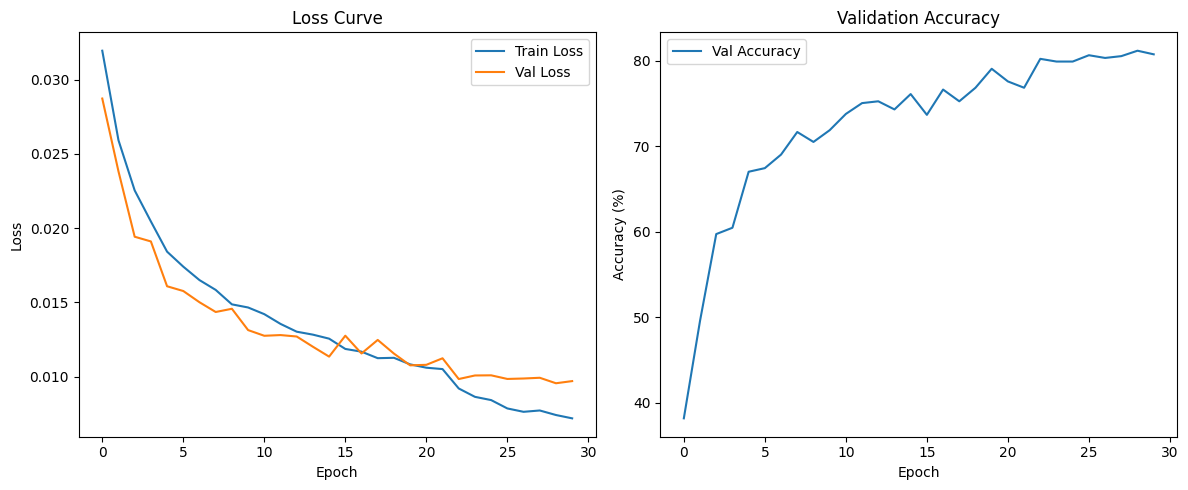

In [88]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

test accuracy: 79.618%


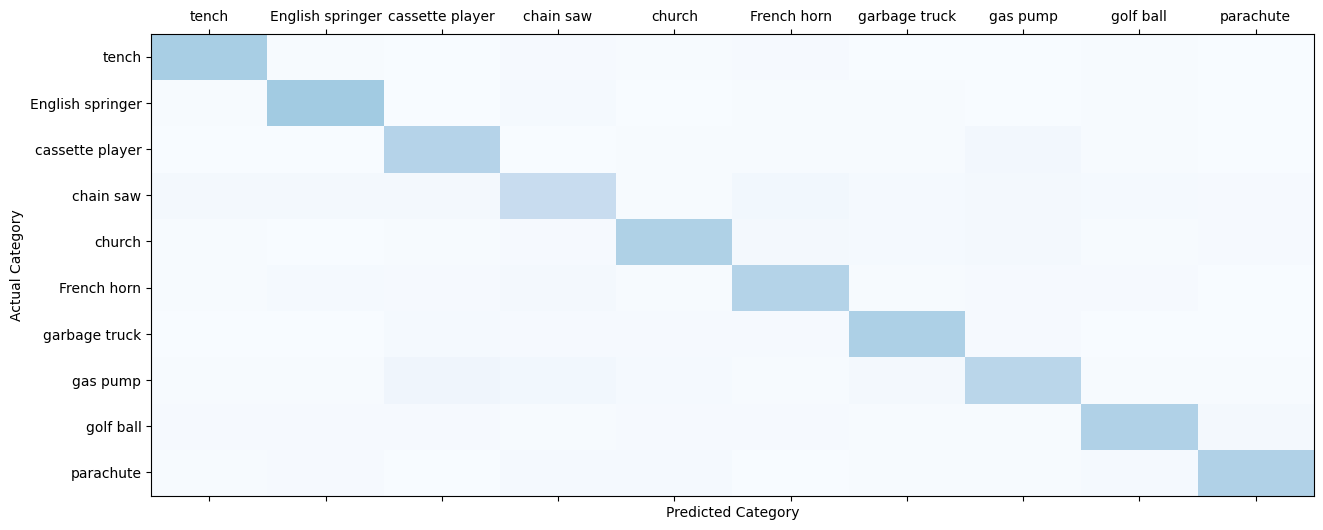

In [89]:
# calculate accuracy and confusion matrix
test_accuracy, confusion_matrix = calculate_accuracy(model, test_loader, device)
print("test accuracy: {:.3f}%".format(test_accuracy))


# plot confusion matrix
fig, ax = plt.subplots(1,1,figsize=(15,6))
ax.matshow(confusion_matrix, aspect='auto', vmin=0, vmax=1000, cmap=plt.get_cmap('Blues'))
plt.ylabel('Actual Category')
plt.yticks(range(10), label_names)
plt.xlabel('Predicted Category')
plt.xticks(range(10), label_names)
plt.show()

Accuracy on the test set has been improved!

## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> Credits
---
* Icons made by <a href="https://www.flaticon.com/authors/becris" title="Becris">Becris</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a>
* Icons from <a href="https://icons8.com/">Icons8.com</a> - https://icons8.com
* Datasets from <a href="https://www.kaggle.com/">Kaggle</a> - https://www.kaggle.com/